In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Step - 1 Data Cleaning

In [3]:
print("="*50)
print("Data Cleaning")
print("="*50)

# Shape and data types 
print(f"Rows = {df.shape[0]}")
print(f"Columns = {df.shape[1]}")
print("\n Data Types")
print(df.dtypes)

# Missing values 
print("\n Missing Values")
missing = df.isnull().sum()
mising_pct = (missing / len(df)) * 100 
print(pd.concat([missing, mising_pct], axis=1, keys=['Count', 'Percent%']))

# Duplicate Rows 
print(f"\nDuplicates: {df.duplicated().sum()}")
print(df[df.duplicated()])
df.drop_duplicates(inplace=True)
print(f"\n✅ After removing duplicates => Shape: {df.shape}")



Data Cleaning
Rows = 1338
Columns = 7

 Data Types
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

 Missing Values
          Count  Percent%
age           0       0.0
sex           0       0.0
bmi           0       0.0
children      0       0.0
smoker        0       0.0
region        0       0.0
charges       0       0.0

Duplicates: 1
     age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631

✅ After removing duplicates => Shape: (1337, 7)


### STEP 2 — EDA (Exploratory Data Analysis)


Columns List: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Dataset info
<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB
None

Statistical Summary
               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39

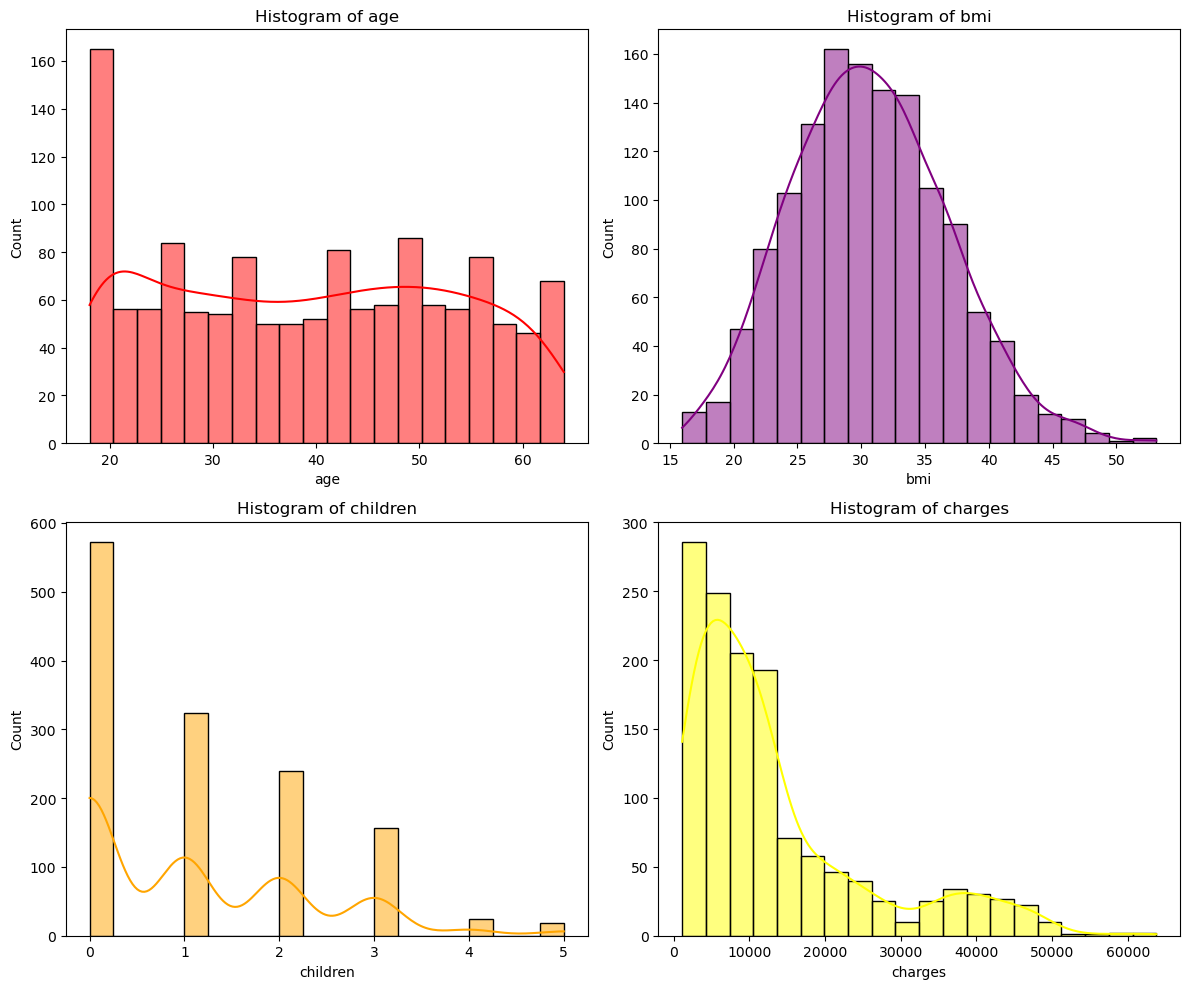


Boxplot of numeric_columns


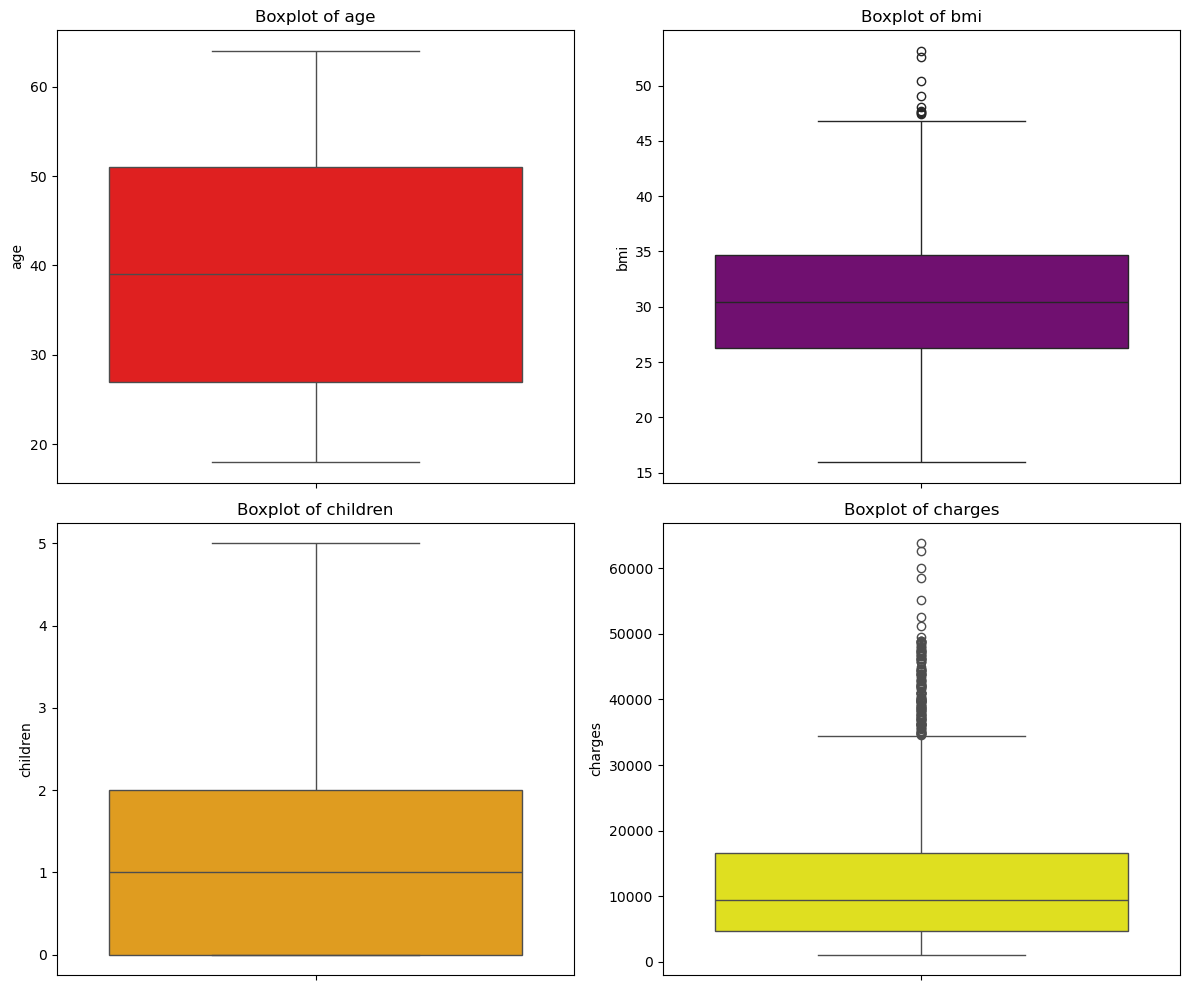

In [4]:
# EDA 

print(f"\nColumns List: {df.columns.to_list()}")

print("\nDataset info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

numeric_cols = ['age', 'bmi', 'children', 'charges']
colors = ['red', 'purple', 'orange', 'yellow']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

print("\nHistogram of numeric_columns")
for i, (col, c) in enumerate(zip(numeric_cols, colors)):
    sns.histplot(df[col], color=c, kde=True, bins=20, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

print("\nBoxplot of numeric_columns")
for i, (col, c) in enumerate(zip(numeric_cols, colors)):
    sns.boxplot(df[col], color=c, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

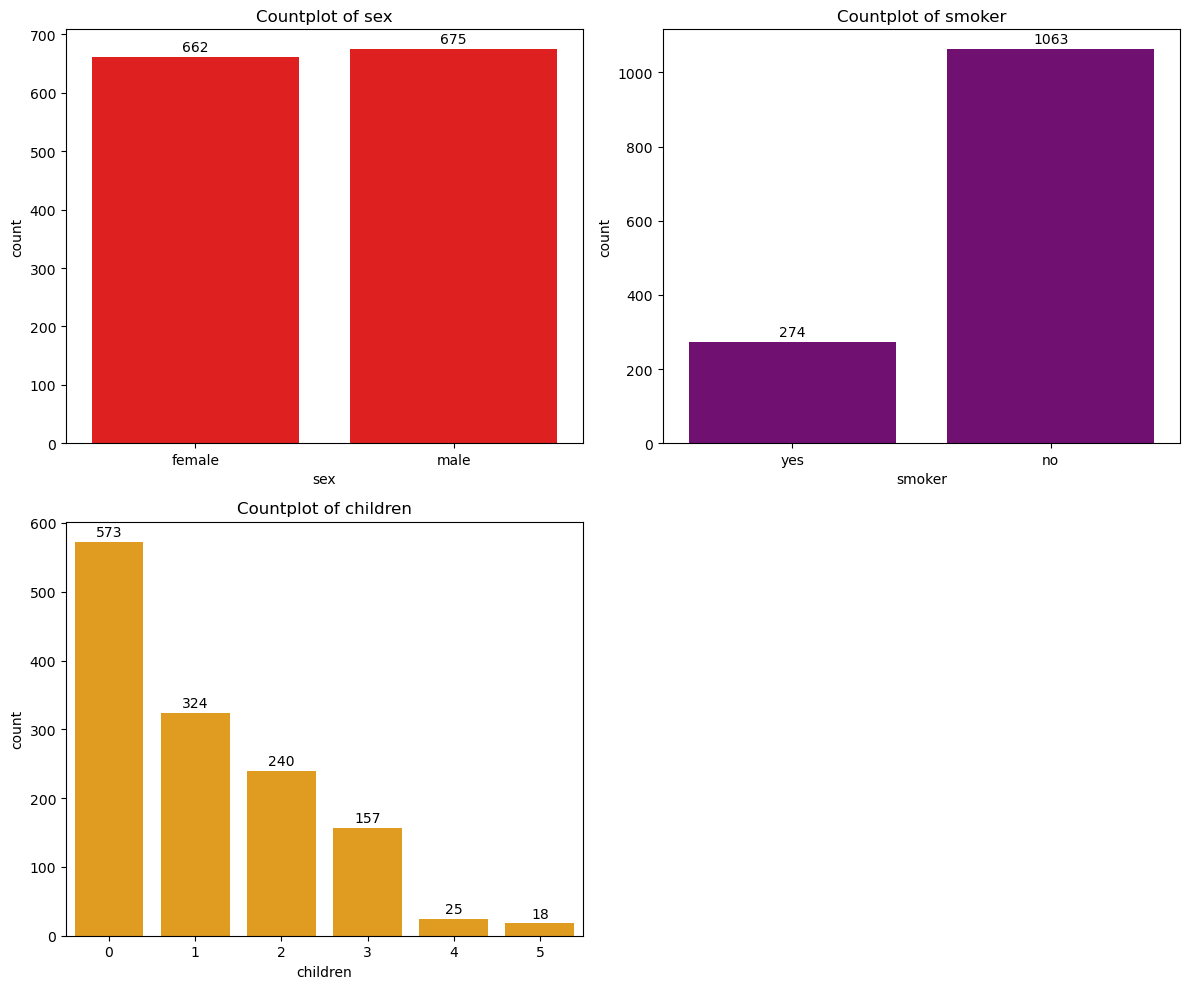

In [5]:

numeric_cols = ['sex', 'smoker', 'children']
colors = ['red', 'purple', 'orange']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (col, c) in enumerate(zip(numeric_cols, colors)):
    sns.countplot(x=df[col], color=c, ax=axes[i])
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', padding=2)
    axes[i].set_title(f'Countplot of {col}')

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

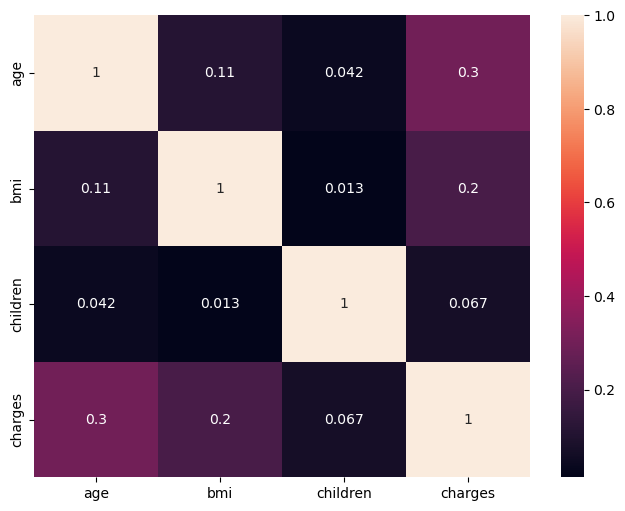


📌 Correlation with Charges (Numerical Features):
charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64


In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

num_cols = ['age', 'bmi', 'children', 'charges']

print("\n📌 Correlation with Charges (Numerical Features):")
target_corr = df[num_cols].corr()['charges'].sort_values(ascending=False)
print(target_corr)

# 💡 Rule: |corr| > 0.3 → useful feature
#          |corr| < 0.1 → likely weak/useless

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

### Step 3 Data Preprocessing (Encoding)

In [9]:
print("\n📌 Categorical Columns:")
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)
print()

for col in cat_cols:
    print(f"  {col}: {df[col].unique()}")

# Label Encoding — Ordinal Features
df['sex'] = df['sex'].map({
    'female' : 1, 
    'male' : 0
})

print("\n✅ Label Encoded: sex (0=male, 1=female)")

df['smoker'] = df['smoker'].map({
    'yes' : 1, 
    'no' : 0
})

print("\n✅ Label Encoded: smoker (0=no, 1=yes)")

# One Hot Encoding — Nominal Features 

df = pd.get_dummies(df, columns=['region'], drop_first = True)
print("\n✅ One Hot Encoded: region")
print(f"\nColumns after encoding: {df.shape[1]}")
print(df.columns.to_list())



📌 Categorical Columns:
['sex', 'smoker', 'region']

  sex: ['female' 'male']
  smoker: ['yes' 'no']
  region: ['southwest' 'southeast' 'northwest' 'northeast']

✅ Label Encoded: sex (0=male, 1=female)

✅ Label Encoded: smoker (0=no, 1=yes)

✅ One Hot Encoded: region

Columns after encoding: 9
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


### STEP 4 — Feature Selection and Extraction

In [10]:
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

df["age_group"] = pd.cut(
    df["age"],
    bins=[0,25,40,60,100],
    labels=['Young', 'Adult', 'Middle Age', 'Senior']
)

df = pd.get_dummies(df, columns=['bmi_category', 'age_group'], drop_first = True)
print("\n✅ Added bmi_category and age_group columns and performed One Hot Encoding")
print(f"\nColumns after encoding: {df.shape[1]}")
print(df.columns.to_list())



✅ Added bmi_category and age_group columns and performed One Hot Encoding

Columns after encoding: 15
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese', 'age_group_Adult', 'age_group_Middle Age', 'age_group_Senior']


In [11]:
# converting bool to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,age_group_Adult,age_group_Middle Age,age_group_Senior
0,19,1,27.900,0,1,16884.92400,0,0,1,0,1,0,0,0,0
1,18,0,33.770,1,0,1725.55230,0,1,0,0,0,1,0,0,0
2,28,0,33.000,3,0,4449.46200,0,1,0,0,0,1,1,0,0
3,33,0,22.705,0,0,21984.47061,1,0,0,1,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0,0,1,0,1,0,0


In [13]:
from scipy.stats import pearsonr
from sklearn.feature_selection import (
    f_regression,
    mutual_info_regression
)
from sklearn.ensemble import RandomForestRegressor 

X = df.drop(columns=['charges'])
y = df['charges']

In [14]:
print("="*60)
print("PEARSON CORRELATION")
print("="*60)

pearson_results = []

for col in X.columns:

    corr, p_value = pearsonr(X[col], y)

    pearson_results.append([
        col,
        round(corr, 4),
        round(p_value, 6)
    ])

pearson_df = pd.DataFrame(
    pearson_results,
    columns=[
        'Feature',
        'Pearson_Correlation',
        'P_Value'
    ]
)

pearson_df = pearson_df.sort_values(
    by='Pearson_Correlation',
    key=abs,
    ascending=False
)

print(pearson_df)

PEARSON CORRELATION
                    Feature  Pearson_Correlation   P_Value
4                    smoker               0.7872  0.000000
0                       age               0.2983  0.000000
2                       bmi               0.1984  0.000000
10       bmi_category_Obese               0.1977  0.000000
12     age_group_Middle Age               0.1791  0.000000
13         age_group_Senior               0.1738  0.000000
9   bmi_category_Overweight              -0.1183  0.000015
11          age_group_Adult              -0.1167  0.000019
8       bmi_category_Normal              -0.1057  0.000109
6          region_southeast               0.0736  0.007113
3                  children               0.0674  0.013717
1                       sex              -0.0580  0.033821
7          region_southwest              -0.0436  0.110742
5          region_northwest              -0.0387  0.157340


In [15]:
print("\n" + "="*60)
print("F REGRESSION TEST")
print("="*60)

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({
    'Feature': X.columns,
    'F_Score': f_scores,
    'P_Value': p_values
})

f_df = f_df.sort_values(
    by='F_Score',
    ascending=False
)

print(f_df)


F REGRESSION TEST
                    Feature      F_Score        P_Value
4                    smoker  2175.736863  1.406722e-282
0                       age   130.402971   6.975749e-29
2                       bmi    54.702715   2.468040e-13
10       bmi_category_Obese    54.278015   3.037576e-13
12     age_group_Middle Age    44.241229   4.222916e-11
13         age_group_Senior    41.566331   1.588280e-10
9   bmi_category_Overweight    18.941668   1.450520e-05
11          age_group_Adult    18.445182   1.875156e-05
8       bmi_category_Normal    15.070787   1.086136e-04
6          region_southeast     7.266644   7.112934e-03
3                  children     6.090326   1.371703e-02
1                       sex     4.513038   3.382079e-02
7          region_southwest     2.546984   1.107417e-01
5          region_northwest     2.001859   1.573396e-01


In [16]:
print("\n" + "="*60)
print("MUTUAL INFORMATION")
print("="*60)

mi_scores = mutual_info_regression(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
})

mi_df = mi_df.sort_values(
    by='MI_Score',
    ascending=False
)

print(mi_df)


MUTUAL INFORMATION
                    Feature  MI_Score
0                       age  1.498718
12     age_group_Middle Age  0.404751
4                    smoker  0.369276
11          age_group_Adult  0.293524
1                       sex  0.176281
3                  children  0.160866
13         age_group_Senior  0.154858
10       bmi_category_Obese  0.085795
2                       bmi  0.073479
5          region_northwest  0.056791
9   bmi_category_Overweight  0.040394
6          region_southeast  0.035002
8       bmi_category_Normal  0.032223
7          region_southwest  0.002465


In [17]:
print("\n" + "="*60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("="*60)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)


RANDOM FOREST FEATURE IMPORTANCE
                    Feature  Importance
4                    smoker    0.619259
2                       bmi    0.203804
0                       age    0.127333
3                  children    0.018937
5          region_northwest    0.005998
1                       sex    0.005571
6          region_southeast    0.005054
7          region_southwest    0.003850
10       bmi_category_Obese    0.003202
9   bmi_category_Overweight    0.003176
8       bmi_category_Normal    0.001796
11          age_group_Adult    0.001025
12     age_group_Middle Age    0.000571
13         age_group_Senior    0.000423


### Interpretation

**Pearson Correlation** 
- Correlation > 0.5      Strong 
- 0.2 to 0.5             Moderate 
- < 0.1                  Weak  

**F-Test (Regression)**  
Higher F Score = More Useful 

P Value < 0.05 
→ Significant Feature 

P Value > 0.05 
→ Candidate for Removal 

**Mutual Information**  
Higher MI Score  =  More Information about Charges

MI = 0 = Feature contributes almost nothing   

**Random Forest Feature Importance**  
How much a model actually uses  
the feature for prediction.  
